In [1]:
# Ex 2.1 Inverse Problems in Earth and Space Physics
# C. Finlay and M. Otzen, DTU Space

In [2]:
%matplotlib inline
import numpy as np    # Use Numpy for linear algebra
import matplotlib.pyplot as plt  # Use matplotlib plotting Package

1 13.0 5.0 13.0 160.0
2 13.0 5.0 6.547213807843101 30.94427615686202
3 13.0 5.0 6.06164388145934 21.232877629186806
4 13.0 5.0 5.910427587998882 18.208551759977638
5 13.0 5.0 5.843059867878458 16.861197357569164
6 13.0 5.0 5.744183188134143 14.88366376268287
7 13.0 5.0 5.615736204863271 12.314724097265426
8 13.0 5.0 5.467636745428792 9.352734908575844
9 13.0 5.0 5.315308143488852 6.306162869777037
10 13.0 5.0 5.17710881444346 3.542176288869196
11 13.0 5.0 5.07237500868799 1.4475001737597992
12 13.0 5.0 5.015774730979143 0.31549461958286784
13 13.0 5.0 5.000902192408947 0.018043848178947997
14 13.0 5.0 5.00000312009101 6.240182019112694e-05
15 13.0 5.0 5.0000000000374465 7.489298070595397e-10
16 13.0 5.0 5.000000000000001 1.7763568394002505e-14
17 13.0 5.0 5.0 0.0
18 13.0 5.0 nan nan
19 13.0 5.0 nan nan
20 13.0 5.0 nan nan


/var/folders/r4/bgq3m75x16s79jqfmfwl57250jdywf/T/ipykernel_41139/3223773000.py:13: RuntimeWarning: divide by zero encountered in divide
  w = 1./abs(epsilon)      # IRLS weights for each data, based on residuals and for
/var/folders/r4/bgq3m75x16s79jqfmfwl57250jdywf/T/ipykernel_41139/3223773000.py:9: RuntimeWarning: invalid value encountered in scalar divide
  med_IRLS = np.sum(w*d)/np.sum(w)      # Present estimate of median


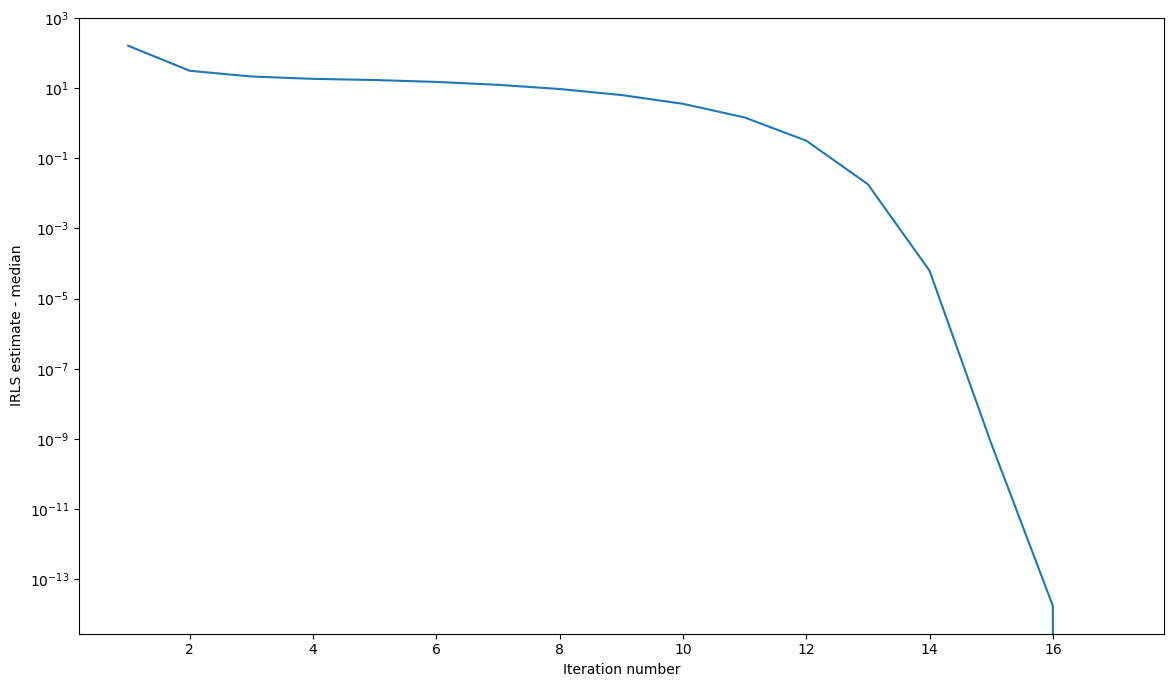

In [3]:
# IRLS estimator of median
d = np.array([1,2,3,4,5,6,7,80,9])   # Define Data Array
w = np.ones(d.shape)                 # Define Array of initial weights, set to 1

niter = np.arange(1,20+1)  # iteration numbers : Try 16 then 20 to show failure 
perc_dif_med = []  # Empty array where will store difference btw IRLS estimate and Numpy's median.

for i in niter:     # Do Iteration
    med_IRLS = np.sum(w*d)/np.sum(w)      # Present estimate of median
    perc_dif_med.append((med_IRLS-np.median(d))/np.median(d)*100)   # % Difference to Numpy's median
    
    epsilon = d - med_IRLS   # Update residuals
    w = 1./abs(epsilon)      # IRLS weights for each data, based on residuals and for 
                              # An expected Laplacian error distribution which results in median Max Lik. Estimator  
    
    print(i, np.mean(d), np.median(d), med_IRLS, perc_dif_med[i-1]) # Print iteration, mean, median, IRLS est, diff 

plt.figure(figsize=(14,8))      
plt.semilogy(niter,perc_dif_med)       # Plots % diff in median and IRLS estimate vs iteration number
plt.xlabel('Iteration number')
plt.ylabel('IRLS estimate - median')
plt.show()

In [4]:
# Huber IRLS
d = np.array([1,2,3,4,5,6,7,80,9]) # Define array
w = np.ones(d.shape)   # d.shape give shape of array d
ones_vect = np.ones(d.shape)  # Define arrays of ones, same length as d needed below

c=1.5 # Threshold number of sigmas for transition from Gaussian to Laplacian in Huber Distribution
niter = np.arange(1,300+1)
perc_dif_med = []
for i in niter:
    huber_mean = np.sum(w*d)/np.sum(w)
    perc_dif_med.append((huber_mean-np.median(d))/np.median(d)*100)
    
    epsilon = d - huber_mean
    
    w = np.min([c/abs(epsilon),ones_vect], axis=0)   # Efficient implementation of Huber weights 
                                                    # Need axis=0 to do min over correct dimension of c/abs(epsilon)
    
    print(i, np.mean(d), np.median(d), perc_dif_med[i-1])

1 13.0 5.0 160.0
2 13.0 5.0 30.94427615686198
3 13.0 5.0 13.319088914133042
4 13.0 5.0 6.264195408910248
5 13.0 5.0 3.0045117381833286
6 13.0 5.0 1.4385109697088794
7 13.0 5.0 0.6893511932355878
8 13.0 5.0 0.33061500232534513
9 13.0 5.0 0.15864002181194437
10 13.0 5.0 0.07613976551631652
11 13.0 5.0 0.03654806650505549
12 13.0 5.0 0.017544609349293694
13 13.0 5.0 0.008422398556202637
14 13.0 5.0 0.004043282063737053
15 13.0 5.0 0.0019410434381228467
16 13.0 5.0 0.0009318325875184995
17 13.0 5.0 0.00044734358956688425
18 13.0 5.0 0.00021475578465768308
19 13.0 5.0 0.00010309762981108861
20 13.0 5.0 4.949400150167093e-05
21 13.0 5.0 2.3760550025286875e-05
22 13.0 5.0 1.1406710758166128e-05
23 13.0 5.0 5.476011821770044e-06
24 13.0 5.0 2.6288652499317777e-06
25 13.0 5.0 1.2620375677840912e-06
26 13.0 5.0 6.05865526637217e-07
27 13.0 5.0 2.908574359139493e-07
28 13.0 5.0 1.3963173728370748e-07
29 13.0 5.0 6.703290367227055e-08
30 13.0 5.0 3.2180427211869755e-08
31 13.0 5.0 1.54488333237168

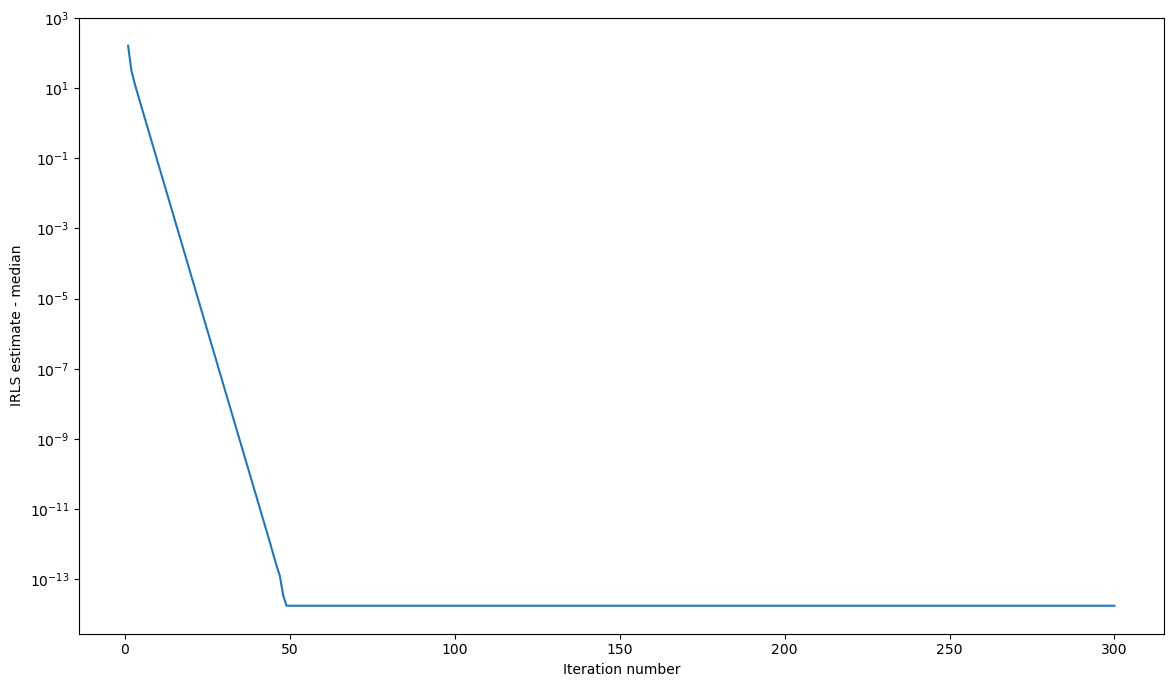

In [5]:
plt.figure(figsize=(14,8))
plt.semilogy(niter,perc_dif_med)    # Plot % diff of Huber estimate to Median vs iteration number
plt.xlabel('Iteration number')
plt.ylabel('IRLS estimate - median')
plt.show()